In [13]:
import torch
print(f"torch.cuda.is_available(): {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")


torch.cuda.is_available(): True
GPU Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [14]:
%pip install pytorch-tabnet

Note: you may need to restart the kernel to use updated packages.


In [15]:
from pytorch_tabnet.tab_model import TabNetClassifier, TabNetRegressor

# Automatically select GPU if available, otherwise use CPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training on device: {DEVICE}")

# Initialize the model with the device parameter
clf = TabNetClassifier(device_name=DEVICE)

# The rest of your training and prediction code follows...
# The library will automatically use the specified device


Training on device: cuda


In [16]:
%pip install timm

Note: you may need to restart the kernel to use updated packages.


In [17]:
%pip install pytorch-tabnet

In [18]:
import torch
import torchvision
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [19]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Akshat Midha\.cache\kagglehub\datasets\atharvaingle\crop-recommendation-dataset\versions\1


In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manikantasanjayv/crop-recommender-dataset-with-soil-nutrients")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Akshat Midha\.cache\kagglehub\datasets\manikantasanjayv\crop-recommender-dataset-with-soil-nutrients\versions\1


In [22]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tmleyncodes/crop-recommendation-using-soil-and-weather")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Akshat Midha\.cache\kagglehub\datasets\tmleyncodes\crop-recommendation-using-soil-and-weather\versions\1


In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jayaprakashpondy/soil-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Akshat Midha\.cache\kagglehub\datasets\jayaprakashpondy\soil-image-dataset\versions\1


In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prasanshasatpathy/soil-types")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Akshat Midha\.cache\kagglehub\datasets\prasanshasatpathy\soil-types\versions\1


In [25]:
# 1. Crop Recommendation Dataset
crop_rec_df = pd.read_csv('crop-recommendation-dataset/Crop_recommendation.csv')
print("Crop Recommendation Dataset:")
print(crop_rec_df.head())
print(crop_rec_df.info())

# 2. Soil Nutrients Dataset
soil_nutrients_df = pd.read_csv('crop-recommender-dataset-with-soil-nutrients/dataset.csv')
print("\nSoil Nutrients Dataset:")
print(soil_nutrients_df.head())
print(soil_nutrients_df.info())

# 3. Crop Recommendation with Weather Dataset
weather_crop_df = pd.read_csv('crop-recommendation-using-soil-and-weather/Crop Recommendation using Soil Properties and Weather Prediction.csv')
print("\nCrop Recommendation with Weather Dataset:")
print(weather_crop_df.head())
print(weather_crop_df.info())

# Optional: Check for missing values in each dataset
print("\nMissing values in Crop Recommendation Dataset:\n", crop_rec_df.isnull().sum())
print("\nMissing values in Soil Nutrients Dataset:\n", soil_nutrients_df.isnull().sum())
print("\nMissing values in Crop Recommendation with Weather Dataset:\n", weather_crop_df.isnull().sum())

Crop Recommendation Dataset:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory us

In [26]:
import torch
from torchvision import transforms

# Define transformations for training images (including data augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # Mean values for ImageNet pretrained models
                         [0.229, 0.224, 0.225])  # Std dev values for ImageNet pretrained models
])

# Define transformations for testing images
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [27]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Set paths for training and testing images
train_dir = 'soil-image-dataset/Train'
test_dir = 'soil-image-dataset/test'

# Load datasets
train_dataset = ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = ImageFolder(root=test_dir, transform=test_transforms)

# Print some information about the datasets
print("Classes in Training Dataset:", train_dataset.classes)
print("Number of training images:", len(train_dataset))
print("Number of test images:", len(test_dataset))

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

Classes in Training Dataset: ['Alluvial soil', 'Black Soil', 'Clay soil', 'Red soil']
Number of training images: 1220
Number of test images: 340


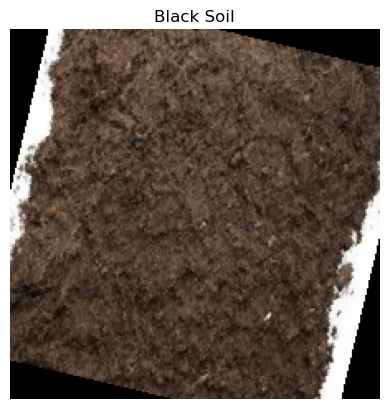

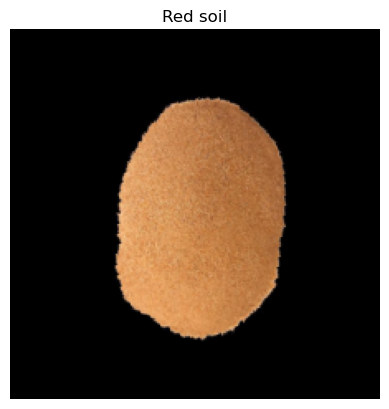

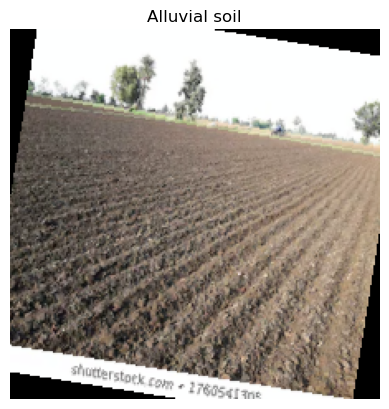

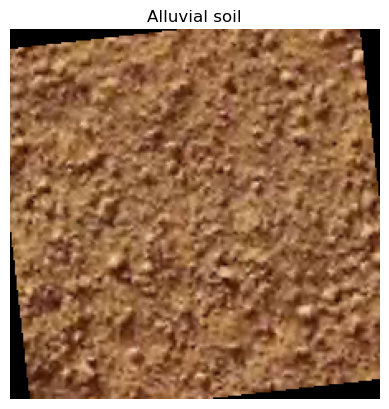

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Function to display an image
def imshow(img, title):
    # unnormalize
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Get a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Display the first 4 images from the batch
for i in range(4):
    imshow(images[i], title=train_dataset.classes[labels[i]])

In [29]:
# Soil Types dataset (e.g., for additional experiments)
soil_types_dir = 'soil-types/Soil types'
soil_types_dataset = ImageFolder(root=soil_types_dir, transform=test_transforms)

print("Soil Types Classes:", soil_types_dataset.classes)
print("Number of images in Soil Types dataset:", len(soil_types_dataset))

Soil Types Classes: ['Black Soil', 'Cinder Soil', 'Laterite Soil', 'Peat Soil', 'Yellow Soil']
Number of images in Soil Types dataset: 156


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(train_dataset.classes)
criterion = nn.CrossEntropyLoss()

def train_and_evaluate(model, optimizer, criterion, num_epochs, train_loader, test_loader, device):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")
    
    # Evaluate on test set
    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
    test_acc = 100 * correct_test / total_test
    print(f"Test Accuracy: {test_acc:.2f}%")

# Using torchvision's EfficientNet-B0
efficientnet_model = models.efficientnet_b0(pretrained=True)
# The classifier is typically a Sequential with Dropout and Linear; we replace the final Linear layer.
num_features = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier[1] = nn.Linear(num_features, num_classes)
efficientnet_model = efficientnet_model.to(device)

# Loss and optimizer
optimizer_efficientnet = optim.Adam(efficientnet_model.parameters(), lr=1e-4)

print("Training EfficientNet-B0 model...")
train_and_evaluate(efficientnet_model, optimizer_efficientnet, criterion, num_epochs=10, 
                   train_loader=train_loader, test_loader=test_loader, device=device)

Training EfficientNet-B0 model...
Epoch [1/10], Loss: 0.8833, Accuracy: 74.43%
Epoch [2/10], Loss: 0.3206, Accuracy: 92.21%
Epoch [3/10], Loss: 0.2107, Accuracy: 94.18%
Epoch [4/10], Loss: 0.1376, Accuracy: 96.23%
Epoch [5/10], Loss: 0.1099, Accuracy: 96.89%
Epoch [6/10], Loss: 0.1001, Accuracy: 97.13%
Epoch [7/10], Loss: 0.0727, Accuracy: 98.20%
Epoch [8/10], Loss: 0.0748, Accuracy: 98.11%
Epoch [9/10], Loss: 0.0562, Accuracy: 98.61%
Epoch [10/10], Loss: 0.0406, Accuracy: 98.77%
Test Accuracy: 99.71%


In [31]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [32]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [33]:
# 1. Load the Crop Recommendation Dataset
df = pd.read_csv('crop-recommendation-dataset/Crop_recommendation.csv')
print("First few rows of the dataset:")
print(df.head())
print("Dataset info:")
print(df.info())

First few rows of the dataset:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), obj

In [34]:
# 2. Preprocessing:
#    - Our target is the 'label' column (the recommended crop).
#    - The original features include: N, P, K, temperature, humidity, ph, rainfall.
#    - We simulate a soil type (which in a deployed system comes from the image classification module).

np.random.seed(42)
df['soil_type'] = np.random.randint(0, 4, size=len(df))
print("\nValue counts for simulated soil_type:")
print(df['soil_type'].value_counts())

# One-hot encode the soil_type column
soil_type_dummies = pd.get_dummies(df['soil_type'], prefix='soil')
df = pd.concat([df.drop('soil_type', axis=1), soil_type_dummies], axis=1)


Value counts for simulated soil_type:
soil_type
0    578
1    545
2    543
3    534
Name: count, dtype: int64


In [35]:
# 3. Separate features and target.
#    The original features: N, P, K, temperature, humidity, ph, rainfall
#    Plus the one-hot encoded soil type features.
X = df.drop('label', axis=1).values  # Feature matrix
y = df['label'].values               # Crop labels

# Convert crop labels (which are strings) into integer labels using LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("\nUnique crop labels:", le.classes_)


Unique crop labels: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [36]:
# 4. Standardize the numerical features.
#    We assume that the first 7 columns are numerical (N, P, K, temperature, humidity, ph, rainfall),
#    and the remaining columns are the one-hot encoded soil type.
scaler = StandardScaler()
X_num = scaler.fit_transform(X[:, :7])
X_cat = X[:, 7:]  # one-hot soil type columns

# Concatenate numerical and categorical features
X_final = np.concatenate([X_num, X_cat], axis=1)

# Convert final feature matrix to float32 to avoid type conversion errors
X_final = X_final.astype(np.float32)
print("\nShape of final feature matrix:", X_final.shape)


Shape of final feature matrix: (2200, 11)


In [37]:
# 5. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_final, y_encoded, test_size=0.2, random_state=42)

In [38]:
# 6. Create a custom PyTorch Dataset for the tabular data
class CropDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CropDataset(X_train, y_train)
test_dataset = CropDataset(X_test, y_test)

# Create DataLoaders for training and testing
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [39]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score

# Create and train the LightGBM classifier
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)

# Make predictions and evaluate accuracy
y_pred_lgb = lgb_model.predict(X_test)
acc_lgb = accuracy_score(y_test, y_pred_lgb)
print("LightGBM Test Accuracy: {:.2f}%".format(acc_lgb * 100))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1347
[LightGBM] [Info] Number of data points in the train set: 1760, number of used features: 11
[LightGBM] [Info] Start training from score -3.129264
[LightGBM] [Info] Start training from score -3.103621
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.169004
[LightGBM] [Info] Start training from score -3.182610
[LightGBM] [Info] Start training from score -3.054228
[LightGBM] [Info] Start training from score -3.054228
[LightGBM] [Info] Start training from score -3.018722
[LightGBM] [Info] Start training from score -3.129264
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -2.984433
[LightGBM] [Info] Start training from score -3.103621


In [40]:
import numpy as np
import torch

# Example custom input:
# Let's say you measured the following:
# N = 90, P = 40, K = 40, temperature = 20°C, humidity = 80%, ph = 6.5, rainfall = 200 mm
# And assume your soil classification model predicts soil type = 1.
# The one-hot encoding for soil type 1 (assuming 4 types: 0, 1, 2, 3) would be: [0, 1, 0, 0]

# Create the raw input vector:
custom_raw = np.array([[90, 40, 40, 20, 80, 6.5, 200]])  # shape (1,7)

# Scale the numerical features using the previously fitted scaler:
custom_num = scaler.transform(custom_raw)  # shape (1,7)

# One-hot part for soil type (predicted by your image model):
custom_soil = np.array([[0, 1, 0, 0]])  # shape (1,4)

# Concatenate to form the final feature vector:
custom_input = np.concatenate([custom_num, custom_soil], axis=1)  # shape (1, 11)
custom_input = custom_input.astype(np.float32)

# Convert to a torch tensor:
custom_tensor = torch.tensor(custom_input, dtype=torch.float32).to(device)

In [41]:
y_pred_lgb = lgb_model.predict(custom_input)
predicted_crop_lgb = le.inverse_transform(y_pred_lgb)
print("LightGBM Predicted Crop:", predicted_crop_lgb[0])

LightGBM Predicted Crop: jute


In [42]:
from torchvision.datasets import ImageFolder
soil_train_dataset = ImageFolder(root=train_dir, transform=train_transforms)

Soil Classification Predictions for the sample image:
EfficientNet-B0     Prediction: Alluvial soil


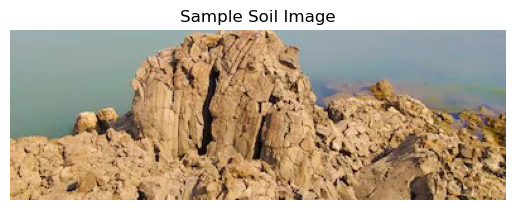

In [43]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Make sure you're using the ImageFolder dataset for soil classification
# For example, if you already defined:
# soil_train_dataset = ImageFolder(root=train_dir, transform=train_transforms)
soil_classes = soil_train_dataset.classes  # This holds the list of class names

# Define a helper function to predict soil type from an image using a given model
def predict_soil_type(image_path, model, transform, class_names):
    model.eval()  # Set model to evaluation mode
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device
    with torch.no_grad():
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)
    predicted_class = class_names[predicted.item()]
    return predicted_class

# Path to a sample soil image (update this path as necessary)
sample_image_path = 'soil-image-dataset/test/Alluvial soil/Alluvial_9.jpg'

# Predict using each model
pred_efficientnet = predict_soil_type(sample_image_path, efficientnet_model, test_transforms, soil_classes)

print("Soil Classification Predictions for the sample image:")
print("EfficientNet-B0     Prediction:", pred_efficientnet)

# Optionally, visualize the sample image
img = Image.open(sample_image_path)
plt.imshow(img)
plt.title("Sample Soil Image")
plt.axis("off")
plt.show()

In [50]:
def predict_soil_type(image_path, model, transform, class_names):
    model.eval()

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)

    soil_idx = predicted.item()
    soil_name = class_names[soil_idx]

    return soil_idx, soil_name


In [51]:
import numpy as np
from PIL import Image

def integrated_crop_recommendation_efficientnet_lgb(
    soil_image_path,
    soil_numerical_values,   # shape (1,7)
    efficientnet_model,
    transform,
    soil_classes,
    scaler,
    lgb_model,
    label_encoder,
    device
):
    """
    Returns:
        predicted_crop (str)
        predicted_soil (str)
    """

    # -----------------------
    # 1. Soil prediction (EfficientNet)
    # -----------------------
    soil_idx, soil_name = predict_soil_type(
        soil_image_path,
        efficientnet_model,
        transform,
        soil_classes
    )

    print("Predicted Soil:", soil_name)

    # -----------------------
    # 2. Scale numerical values
    # -----------------------
    soil_numerical_values = np.array(soil_numerical_values).reshape(1, 7)
    num_scaled = scaler.transform(soil_numerical_values)

    # -----------------------
    # 3. One-hot encode soil
    # -----------------------
    num_soil_classes = len(soil_classes)
    soil_onehot = np.zeros((1, num_soil_classes))
    soil_onehot[0, soil_idx] = 1

    # -----------------------
    # 4. Final LightGBM input
    # -----------------------
    final_input = np.concatenate([num_scaled, soil_onehot], axis=1).astype(np.float32)

    # -----------------------
    # 5. Crop prediction (LightGBM)
    # -----------------------
    y_pred = lgb_model.predict(final_input)
    crop_name = label_encoder.inverse_transform(y_pred)[0]

    print("Predicted Crop:", crop_name)

    return crop_name, soil_name


In [55]:
soil_image = "soil-image-dataset/test/Black Soil/Black_1.jpg"

numerical = [[    78,     # Nitrogen (kg/ha)
    36,     # Phosphorus (kg/ha)
    42,     # Potassium (kg/ha)
    27.5,   # Temperature (°C)
    68,     # Humidity (%)
    6.4,    # pH
    185     # Rainfall (mm)
]]

crop, soil = integrated_crop_recommendation_efficientnet_lgb(
    soil_image_path=soil_image,
    soil_numerical_values=numerical,
    efficientnet_model=efficientnet_model,
    transform=test_transforms,
    soil_classes=soil_train_dataset.classes,
    scaler=scaler,
    lgb_model=lgb_model,
    label_encoder=le,
    device=device
)


Predicted Soil: Black Soil
Predicted Crop: coffee


In [56]:
import joblib
import numpy as np
import torch

# Create folder
import os
os.makedirs("saved_models", exist_ok=True)

# 1. Save EfficientNet
torch.save(efficientnet_model.state_dict(), "saved_models/efficientnet.pth")

# 2. Save LightGBM
joblib.dump(lgb_model, "saved_models/lgb_model.pkl")

# 3. Save scaler
joblib.dump(scaler, "saved_models/scaler.pkl")

# 4. Save label encoder
joblib.dump(le, "saved_models/label_encoder.pkl")

# 5. Save soil classes
np.save("saved_models/soil_classes.npy", soil_train_dataset.classes)

print("✅ All models saved successfully!")


✅ All models saved successfully!
